In [ ]:
from fastapi import APIRouter
from services.sentiment import Sentiment_analysis
from services.patterns import pattern_analysis
from services.insights import Insight_generation
from services.memory import Memory_save
from services.personal_knowledge_grain import personal_knowledge_grain
from langgraph.graph import StateGraph,START,END
from langchain_core.messages import HumanMessage
from langchain_google_genai import ChatGoogleGenerativeAI
from pydantic import BaseModel
from typing import TypedDict,Optional
from dotenv import load_dotenv
from utils.state import MindJournal
import uuid  

In [18]:
load_dotenv()

True

In [19]:
class MindJournal(TypedDict):
    query: str
    orchestration:Optional[dict]

In [20]:
llm = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite-preview")

In [21]:
def Agent_Planning(state : MindJournal)-> MindJournal:
    query = state['query']

    prompt = f"""
    You are the planning core of Mind Mirror — an emotionally intelligent journaling agent.
    You have 10+ years of experience in cognitive behavioral therapy, emotional pattern recognition, 
    and human psychology. You deeply understand how people express pain, joy, confusion, 
    and growth through their writing.

    Your ONLY job is to deeply read this journal entry and extract a rich understanding of it
    so that the Sentiment, Pattern, and Insight tools can work accurately.

    ---
    JOURNAL ENTRY:
    \"\"\"{query}\"\"\"
    ---

    Return ONLY this JSON:

    {{
    "emotional_summary": "<1 warm, human sentence capturing the core feeling of this entry>",
    "key_entities": ["<people, places, goals, habits, or themes explicitly mentioned>"],
    "urgency": "<low | medium | high>",
    "context_for_tools": "<2-3 sentences elaborating what the tools should focus on — what is this person really going through?>"
    }}

    STRICT RULES:
    - Return ONLY JSON. Zero extra text or markdown.
    - Never invent anything not present in the entry.
    - emotional_summary must feel human and empathetic, never clinical.
    - urgency is high only if user expresses distress, hopelessness, or crisis signals.
    - If entry is under 5 words: emotional_summary = "Entry too short", key_entities = [], urgency = "low", context_for_tools = "Insufficient text to analyze."
    """

    import json, re
    response = llm.invoke(prompt)
    raw = re.sub(r"```json|```", "", response.content.strip()).strip()
    plan = json.loads(raw)

    return {
        "orchestration" : plan
    }

In [22]:
def Sentiment_analysis(state : MindJournal)-> MindJournal:
     query = state['query']
     context = state['orchestration']['context_for_tools']
     emotional_summary = state['orchestration']['emotional_summary']

     prompt = f"""
You are an expert in cognitive behavioral therapy and emotional analysis.
You have 10+ years of experience identifying emotional patterns in human writing.

The planning agent has already read this entry and noted:
- Emotional summary: {emotional_summary}
- Context: {context}

Now analyze this journal entry in depth:
\"\"\"{query}\"\"\"

Return ONLY this JSON:
{{
  "energy_score": <integer 1-10>,
  "mood": "<positive | negative | neutral | mixed>",
  "primary_emotion": "<single dominant emotion>",
  "cognitive_distortions": ["<list any: catastrophizing | all-or-nothing | self-blame | mind-reading | overgeneralization | none>"],
  "sentiment_score": <float -1.0 to 1.0>
}}

STRICT RULES:
- Return ONLY JSON. No extra text.
- energy_score 1 = completely drained, 10 = highly energized
- sentiment_score -1 = very negative, 0 = neutral, 1 = very positive
- cognitive_distortions must always be a list
"""
     import json
     import re
     response = llm.invoke(prompt)
     raw = re.sub(r"```json|```", "", response.content.strip()).strip()
     result = json.loads(raw)

     return {
        **state,
        "sentiment_result": result
    }

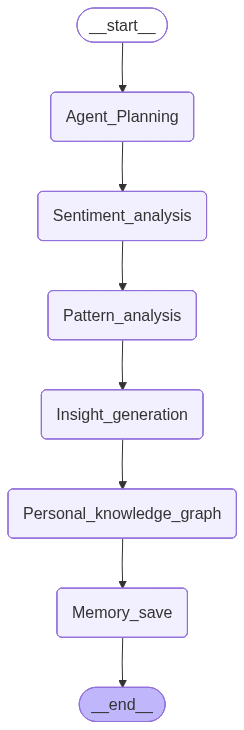

In [26]:
# initializing the graph
graph = StateGraph(MindJournal)

# creating the nodes
graph.add_node("Agent_Planning",         Agent_Planning)
graph.add_node("Sentiment_analysis",     Sentiment_analysis)
graph.add_node("Pattern_analysis",       pattern_analysis)
graph.add_node("Insight_generation",     Insight_generation)
graph.add_node("Memory_save",            Memory_save)
graph.add_node("Personal_knowledge_graph", personal_knowledge_grain)

# connecting the nodes — sequential flow
graph.add_edge(START,                    "Agent_Planning")
graph.add_edge("Agent_Planning",         "Sentiment_analysis")
graph.add_edge("Sentiment_analysis",     "Pattern_analysis")
graph.add_edge("Pattern_analysis",       "Insight_generation")
graph.add_edge("Insight_generation",     "Personal_knowledge_graph")
graph.add_edge("Personal_knowledge_graph", "Memory_save")
graph.add_edge("Memory_save",            END)

# compiling the graph
workflow = graph.compile()

workflow

In [24]:
result = workflow.invoke({"query":"iam feeling very addicted to the phone"})
print(result)

KeyError: 'user_id'